# Feminicídio nos municípios de São Paulo — base, decisões metodológicas e análise exploratória

**Insper Data × Consilium · Pesquisa 2026.1 · Orientação: Profa. Dra. Maria Kelly Venezuela (Estatística)**

> **Pergunta de pesquisa:** *Quais fatores socioeconômicos se associam à taxa de feminicídio nos municípios do estado de São Paulo?*

Este notebook é **autocontido**: para rodá-lo bastam dois arquivos na mesma pasta — `analise_final.ipynb` e `painel_feminicidio_sp.csv`. A malha geográfica dos municípios (para os mapas) é baixada automaticamente do IBGE na seção espacial.

**Como ler.** As seções **0–4** explicam *de onde vêm os dados, o que cada variável significa e por que cada decisão foi tomada* — é o "porquê" do projeto. A **Parte II** é a Análise Exploratória (EDA), com código, gráficos e interpretação. Fique à vontade para editar células e re-rodar (`Run All`).

## 0. Contexto e enquadramento teórico

O feminicídio — assassinato de uma mulher *por razões da condição de sexo feminino* (Lei 13.104/2015) — é a forma extrema da violência de gênero. A pergunta do projeto **não** é descrever *quantos* casos há, e sim *que características dos municípios* se associam a taxas mais altas, gerando subsídio para política pública.

Duas teorias clássicas da criminologia orientam a escolha dos fatores:

- **Desorganização Social (Shaw & McKay, 1942):** o crime se concentra onde há privação econômica, baixa escolaridade e fragilidade dos laços comunitários → motiva olhar **renda** e **educação** municipais.
- **Atividade de Rotina (Cohen & Felson, 1979):** o crime depende do encontro entre ofensor motivado, alvo e ausência de guardião → motivará, na Fase 2, indicadores de proteção institucional.

⚠️ Este é um estudo **observacional/associativo**: correlação entre um fator e a taxa **não** prova causalidade — há confundidores (a própria população do município é um deles, como a EDA mostra).

## 1. A base de dados: `painel_feminicidio_sp.csv`

É um **painel município × ano**: 645 municípios × 4 anos (2022–2025) = **2.580 linhas × 17 colunas**. **Cada linha = um município em um ano**, combinando os feminicídios *daquele ano* com o perfil socioeconômico e de contexto *do município*.

Resulta de um pipeline em camadas (`raw → processed → final`) que cruza várias fontes:

| Fonte | O que fornece |
|---|---|
| **SSP-SP** (Boletins de Ocorrência) | feminicídios (consumado e tentativa) e **tráfico de drogas**, 2022–2025 |
| **IBGE** (estimativas populacionais) | população total por município e ano (denominador das taxas) |
| **Censo 2022 / SIDRA** | educação (alfabetização, anos de estudo, instrução), **urbanização** e **saneamento** (rede de água) dos domicílios |
| **PIB municipal** (IBGE) | atividade econômica → PIB per capita |

O cruzamento usa o **código IBGE de 7 dígitos** (`id_municipio`). Os nomes de município dos BOs da SSP vêm abreviados (`S.JOSE DO RIO PARDO`, `ESTRELA D OESTE`) e são casados ao código por uma **chave textual canônica** robusta a essas grafias (`src/municipio_sp.py`), validada para casar 100% dos BOs paulistas de feminicídio **e** de tráfico.

**Há dois tipos de coluna — distinção central para a modelagem:**
- **Variam no tempo:** contagens (`n_*`), as taxas de feminicídio (`taxa_feminicidio_*`) e de **tráfico** (`taxa_trafico_drogas_100k`), e `populacao`.
- **Fixas no município (Censo 2022):** os preditores socioeconômicos, **urbanização** e **saneamento** — *repetidos* nos 4 anos. Sua variação é **só entre municípios**, não no tempo.

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re

In [2]:
# painel_feminicidio_sp.csv é separado por VÍRGULA e salvo em utf-8-sig (com BOM).
# sep=";" lia tudo como 1 coluna só; encoding="utf-8-sig" remove o BOM do nome "id_municipio".
painel = pd.read_csv("painel_feminicidio_sp.csv", encoding="utf-8-sig")
print(painel.shape)  # esperado: (2580, 17)
painel.columns.tolist()

(2580, 17)


['id_municipio',
 'municipio',
 'ano',
 'n_consumado',
 'n_total',
 'n_tentativa',
 'taxa_feminicidio_consumado_100k',
 'taxa_feminicidio_total_100k',
 'populacao',
 'pib_per_capita_2022',
 'taxa_alfabetizacao',
 'anos_medios_estudo',
 'pct_ensino_medio',
 'pct_ensino_superior',
 'taxa_urbanizacao_pct',
 'taxa_saneamento_basico_pct',
 'taxa_trafico_drogas_100k']

In [3]:
painel.head()

,id_municipio,municipio,ano,n_consumado,n_total,n_tentativa,taxa_feminicidio_consumado_100k,taxa_feminicidio_total_100k,populacao,pib_per_capita_2022,taxa_alfabetizacao,anos_medios_estudo,pct_ensino_medio,pct_ensino_superior,taxa_urbanizacao_pct,taxa_saneamento_basico_pct,taxa_trafico_drogas_100k
0,3500105,Adamantina,2022,0,1,1,0.0,2.882924,34687,44457.830542,0.964921,10.5,0.604988,0.219819,96.922624,97.018332,95.136506
1,3500105,Adamantina,2023,0,0,0,0.0,0.000000,34687,44457.830542,0.964921,10.5,0.604988,0.219819,96.922624,97.018332,54.775564
2,3500105,Adamantina,2024,0,0,0,0.0,0.000000,35642,44457.830542,0.964921,10.5,0.604988,0.219819,96.922624,97.018332,112.227148
3,3500105,Adamantina,2025,0,0,0,0.0,0.000000,35673,44457.830542,0.964921,10.5,0.604988,0.219819,96.922624,97.018332,81.293976
4,3500204,Adolfo,2022,0,0,0,0.0,0.000000,4351,35105.714778,0.932213,8.4,0.414821,0.104813,92.666667,88.424242,298.781889


## 2. As variáveis — o que são e *por que* foram escolhidas

### 2.1 O desfecho: por que separar consumado, tentativa e total

A base traz três contagens por município-ano — `n_consumado`, `n_tentativa`, `n_total` (= soma) — e as taxas correspondentes. A distinção **não é detalhe técnico**; muda o que se mede:

- **Consumado** (`NATUREZA_APURADA = "HOMICÍDIO DOLOSO"`): a mulher **foi morta**.
- **Tentativa:** houve tentativa de matar, mas a vítima **sobreviveu**.

No período, **69% dos registros são tentativas** (1.136 de 1.636). Usar `n_total` e chamar de "feminicídio" superestimaria as *mortes* em ~3×. Por isso:

- **Principal: `taxa_feminicidio_consumado_100k`** — é o feminicídio no sentido legal e da literatura (a morte) e sofre **menos viés de notificação** (um óbito quase sempre é registrado; já *classificar* uma tentativa depende da denúncia e do enquadramento policial).
- **Robustez: `taxa_feminicidio_total_100k`** — consumado + tentativa, para checar se as conclusões se mantêm sob uma definição mais ampla de "violência feminicida".

> As duas taxas convivem **na mesma base** (não em dois arquivos): cada regressão escolhe a coluna-alvo.

### 2.2 A taxa e o denominador: por que população *total*

`taxa = (nº de feminicídios / população) × 100.000`. Dividir pela população **normaliza pelo tamanho** do município (sem isso, a capital lideraria qualquer ranking só por ser grande); o `× 100.000` é a convenção epidemiológica para eventos raros.

**Decisão travada:** denominador = **população total**, não feminina, porque (i) a base populacional usada aqui não vem desagregada por sexo e (ii) a escolha padroniza todas as taxas (acordado com a orientação). O relatório será corrigido para "por 100 mil **habitantes**".

### 2.3 Os preditores socioeconômicos (Censo 2022)

Cobrem **dois construtos** que as teorias indicam: **renda** e **educação**.

| Variável | O que mede | Por que está aqui |
|---|---|---|
| `pib_per_capita_2022` | atividade econômica por habitante | proxy de desenvolvimento econômico (com ressalva, ver 2.4) |
| `taxa_alfabetizacao` | % de alfabetizados (15+) | **piso** educacional; o indicador mais distinto dos demais |
| `anos_medios_estudo` | anos médios de estudo (11+) | **resumo contínuo** da escolaridade; o mais interpretável |
| `pct_ensino_medio` | % 18+ com médio completo ou + | limiar intermediário, interpretável p/ política |
| `pct_ensino_superior` | % 18+ com superior completo | **topo** da distribuição; alta variância → discrimina bem |

A lógica foi cobrir a distribuição educacional em três "alturas" (piso = alfabetização; meio = anos de estudo/médio; topo = superior) com **poucas variáveis não redundantes**, em vez de dezenas de recortes.

### 2.4 O que foi *descartado* — e por quê

Reduzir redundância importa tanto quanto incluir: preditores quase idênticos inflam a multicolinearidade sem acrescentar informação.

| Descartado | Motivo |
|---|---|
| Recortes **femininos** (`*_fem`) de educação | r ≈ **0,97** com a versão total → quase duplicatas |
| `pib_2023` | r ≈ **0,9998** com `pib_2022` → praticamente a mesma coluna |
| Recorte por **raça** | os CSVs do SIDRA vieram **sem** desagregação por cor (só "Total"); reextrair é opção de download → fica para depois |
| Faixas baixas de instrução (sem instr./fundamental) | as 4 faixas do SIDRA somam 100% → usar todas é colinearidade perfeita; o "fundo" já está em `taxa_alfabetizacao` e no complemento de `pct_ensino_medio` |

> ⚠️ **Ressalva do PIB per capita:** mede *onde a economia acontece*, não a renda das pessoas. É inflado por enclaves industriais (Paulínia/refinaria, Ilhabela, Gavião Peixoto/Embraer). Na Fase 2, a intenção é substituí-lo/complementá-lo por **rendimento domiciliar per capita** (Censo 2022).

### 2.5 Variáveis de contexto adicionadas (enriquecimento — Fase 1)

Três variáveis foram acrescentadas para ampliar os construtos além de renda/educação, cobrindo **infraestrutura urbana** e **contexto de criminalidade** — ambos sugeridos pelas teorias da seção 0 (Desorganização Social e Atividade de Rotina).

| Variável | O que mede | Fonte | Por que está aqui |
|---|---|---|---|
| `taxa_urbanizacao_pct` | % de domicílios em área urbana | Censo 2022 / SIDRA 9922 | proxy direta de **urbanização** — o confundidor que a EDA já apontava (mais urbano ⇒ melhores indicadores **e** mais registro de eventos) |
| `taxa_saneamento_basico_pct` | % de domicílios ligados à rede geral de água | Censo 2022 / SIDRA 6803 | proxy de **infraestrutura/privação** material do município |
| `taxa_trafico_drogas_100k` | BOs de tráfico (Art. 33) por 100 mil hab. | SSP-SP (mesma base de BOs do feminicídio) | proxy de **criminalidade / mercados ilícitos** — único preditor que **varia no tempo** |

**Como foram construídas (transparência para reuso).**
- **Urbanização** e **saneamento** são razões `(domicílios na categoria / total) × 100` do Censo 2022 → **fixas no município**, replicadas nos 4 anos (como os demais preditores). Cobrem os 645 municípios, sem nulos.
- **Tráfico** segue **exatamente a mesma receita do feminicídio**: contagem de BOs por município-ano ÷ população × 100.000. Vem da **mesma base bruta de BOs da SSP**, *antes* do filtro de feminicídio, isolando a rubrica de tráfico (Art. 33, *caput*; exclui o Art. 28 / consumo pessoal).

> ⚠️ **Correção de cruzamento (auditada).** A primeira versão do tráfico zerava ~32 municípios paulistas por falha de match dos nomes abreviados da SSP (ex.: **São José do Rio Pardo**, com 440 BOs, aparecia como 0). A causa: o cruzamento estava calibrado só para o universo (pequeno) do feminicídio. A chave textual foi **generalizada e revalidada** — agora casa 100% dos BOs de SP; só ficam de fora registros genuinamente de outros estados (Poços de Caldas/MG etc.). Os municípios que permanecem com tráfico = 0 são **zeros reais** (8 municípios < 3 mil hab., sem nenhum BO de tráfico).

## 3. Decisões metodológicas travadas (Fase 0)

Resumo para referência rápida (detalhes em 2.1–2.2):

| Decisão | Escolha | Por quê (resumo) |
|---|---|---|
| Desfecho principal | **consumado** | é o feminicídio no sentido legal (a morte); menos viés de notificação |
| Desfecho de robustez | **total** (consumado + tentativa) | testa se as conclusões se mantêm sob definição mais ampla |
| Denominador da taxa | **população total** | base sem desagregação por sexo; padroniza as taxas |
| Estrutura | **uma base, duas taxas** | evita duplicar preditores em dois arquivos |

Essas decisões estão **encerradas** — o foco agora é a análise, não rediscuti-las.

## 4. Alertas metodológicos — leia antes de confiar nos números

Achados de auditoria da base (verificados nos dados, não são opiniões):

1. **A base mistura consumado e tentativa.** O filtro original foi por *descrição da conduta*, não por desfecho → ~69% são tentativas. Por isso as colunas vêm separadas.
2. **2022 está "quebrado" para consumado:** 100% dos registros de 2022 estão como *tentativa* (0 consumados) — artefato de preenchimento, não realidade. **→ Por isso a EDA exclui 2022** e agrega o consumado apenas em **2023–2025**.
3. **Pico de 2024** (≈ o dobro dos demais anos), concentrado em *tentativas* — provável mudança de classificação/cobertura; investigar antes de ler como tendência.
4. **Muitos zeros:** a maioria dos municípios não tem caso (feminicídio é raro) → exige modelos de contagem, não regressão linear (mostrado empiricamente na EDA).
5. **Preditores fixos no tempo** (Censo 2022): não variam entre 2022–2025 → a análise é, na prática, **transversal** (entre municípios). Por isso a EDA roda em *cross-section* (1 linha por município).

> Documentação completa do pipeline e dos alertas vive em `docs/` no repositório; aqui consolidamos o essencial para o notebook ser autossuficiente.

# Parte II — Análise Exploratória de Dados (EDA)

**Objetivo:** antes de estimar qualquer modelo, entender (i) a distribuição do desfecho, (ii) sua relação bivariada com cada preditor, (iii) a multicolinearidade entre preditores e (iv) padrões espaciais — produzindo evidência para *escolher o modelo econométrico certo*.

**Unidade de análise: município (cross-section, 645 obs.).** Como os preditores são fixos em 2022 (alerta nº 5), usar o painel de 2.580 linhas replicaria cada preditor 4× (pseudo-replicação) e distorceria correlações, VIF e mapas. Por isso colapsamos para **um registro por município**.

**Desfecho da EDA (`taxa_consumado_100k`)** = (Σ consumados em **2023–2025**) / população média × 100.000. Excluímos **2022** pelo artefato do alerta nº 2.

In [4]:
import json
import matplotlib.colors as mcolors
from matplotlib.patches import Polygon as MplPoly
from matplotlib.collections import PatchCollection
sns.set_theme(style="whitegrid", context="notebook")

# Preditores fixos no município (Censo 2022) + os de contexto adicionados na Fase 1.
PRED_FIX = ["pib_per_capita_2022", "taxa_alfabetizacao", "anos_medios_estudo",
            "pct_ensino_medio", "pct_ensino_superior",
            "taxa_urbanizacao_pct", "taxa_saneamento_basico_pct"]
# tráfico VARIA no tempo -> tratado à parte (agregado como o desfecho).
PRED = PRED_FIX + ["taxa_trafico_drogas_100k"]
ROTULO = {"pib_per_capita_2022": "PIB per capita 2022 (R$)", "taxa_alfabetizacao": "Taxa de alfabetização",
          "anos_medios_estudo": "Anos médios de estudo", "pct_ensino_medio": "% ensino médio completo+",
          "pct_ensino_superior": "% ensino superior completo",
          "taxa_urbanizacao_pct": "% domicílios urbanos", "taxa_saneamento_basico_pct": "% domic. c/ rede de água",
          "taxa_trafico_drogas_100k": "Tráfico de drogas / 100 mil hab."}

# cross-section: consumados agregados em 2023-2025 (exclui 2022 = artefato)
sub = painel[painel["ano"].isin([2023, 2024, 2025])].copy()
# tráfico é taxa anual; reconstruímos a contagem p/ agregar pela MESMA receita do desfecho
sub["n_trafico"] = (sub["taxa_trafico_drogas_100k"] / 1e5 * sub["populacao"]).round()
cs = (sub.groupby(["id_municipio", "municipio"])
         .agg(n_consumado=("n_consumado", "sum"), pop_media=("populacao", "mean"),
              n_trafico=("n_trafico", "sum"),
              **{p: (p, "first") for p in PRED_FIX})
         .reset_index())
cs["taxa_consumado_100k"] = cs["n_consumado"] / cs["pop_media"] * 1e5
cs["taxa_trafico_drogas_100k"] = cs["n_trafico"] / cs["pop_media"] * 1e5
Y = "taxa_consumado_100k"
print("cross-section:", cs.shape)
cs.head()

cross-section: (645, 14)


,id_municipio,municipio,n_consumado,pop_media,n_trafico,pib_per_capita_2022,taxa_alfabetizacao,anos_medios_estudo,pct_ensino_medio,pct_ensino_superior,taxa_urbanizacao_pct,taxa_saneamento_basico_pct,taxa_consumado_100k,taxa_trafico_drogas_100k
0,3500105,Adamantina,0,35334.000000,88.0,44457.830542,0.964921,10.5,0.604988,0.219819,96.922624,97.018332,0.000000,249.051905
1,3500204,Adolfo,0,4444.666667,16.0,35105.714778,0.932213,8.4,0.414821,0.104813,92.666667,88.424242,0.000000,359.982001
2,3500303,Aguaí,1,32615.333333,112.0,47979.196714,0.950341,9.0,0.432342,0.122281,93.614983,93.362369,3.066043,343.396766
3,3500402,Águas da Prata,0,7434.000000,18.0,32222.462614,0.968494,9.4,0.496132,0.160108,87.844523,89.858657,0.000000,242.130751
4,3500501,Águas de Lindóia,0,18144.000000,81.0,39575.548132,0.964114,9.5,0.509516,0.160392,87.777614,94.102074,0.000000,446.428571


## 1. Distribuição do desfecho

count    645.000
mean       1.411
std        4.104
min        0.000
50%        0.000
75%        0.786
90%        3.823
95%        8.041
99%       19.889
max       38.032

Proporção de zeros: 71.3%  (460/645 municípios)
Assimetria (skew): 4.77
Municípios com >=1 consumado (2023-2025): 185


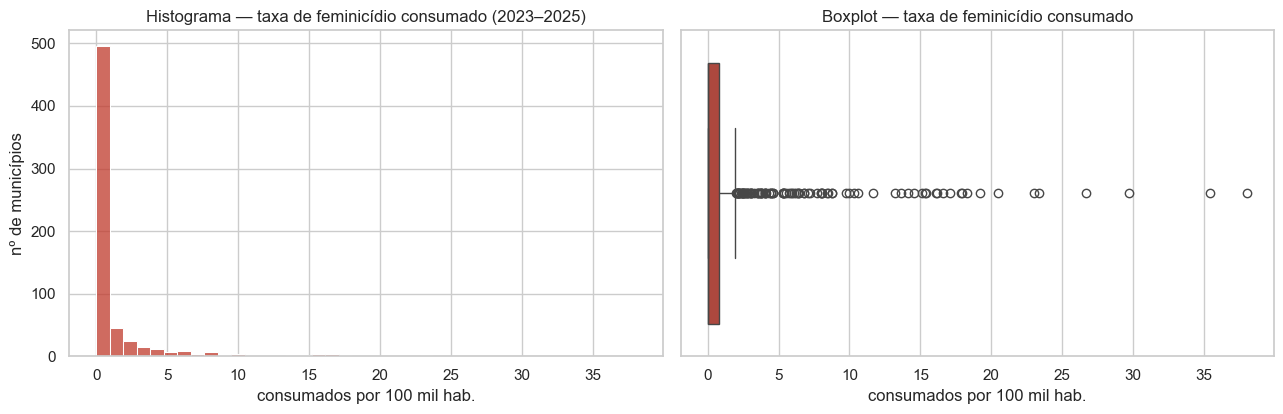

In [5]:
desc = cs[Y].describe(percentiles=[.5, .75, .9, .95, .99])
print(desc.round(3).to_string())
print(f"\nProporção de zeros: {(cs[Y]==0).mean():.1%}  ({int((cs[Y]==0).sum())}/{len(cs)} municípios)")
print(f"Assimetria (skew): {cs[Y].skew():.2f}")
print(f"Municípios com >=1 consumado (2023-2025): {(cs.n_consumado>0).sum()}")

fig, ax = plt.subplots(1, 2, figsize=(13, 4.3))
sns.histplot(cs[Y], bins=40, ax=ax[0], color="#c0392b")
ax[0].set(title="Histograma — taxa de feminicídio consumado (2023–2025)",
          xlabel="consumados por 100 mil hab.", ylabel="nº de municípios")
sns.boxplot(x=cs[Y], ax=ax[1], color="#c0392b")
ax[1].set(title="Boxplot — taxa de feminicídio consumado", xlabel="consumados por 100 mil hab.")
plt.tight_layout(); plt.show()

**Interpretação.** A distribuição é fortemente **assimétrica à direita** (skew ≈ 4,8) e dominada por **excesso de zeros**: **71,3%** dos municípios (460/645) não registraram nenhum feminicídio consumado em 2023–2025; a **mediana é 0**. Só a partir do 3º quartil a taxa fica positiva, e a cauda chega a ~38 por 100 mil — municípios pequenos em que 1 caso vira taxa enorme.

**Por que OLS é inadequado.** (i) Os resíduos não serão aproximadamente normais — há uma massa de probabilidade em zero e cauda longa; (ii) a taxa por 100 mil é **instável em municípios pequenos** (1 evento → taxa desproporcional); (iii) OLS pode prever taxas negativas. O desfecho é, na origem, uma **contagem de eventos raros com exposição variável (população)**. → O caminho correto são **modelos de contagem** (Poisson; Binomial Negativa se houver sobredispersão) com **offset `log(população)`**, possivelmente com **inflação de zeros** (zero-inflated/hurdle).

## 2. Análise bivariada (desfecho × preditores)

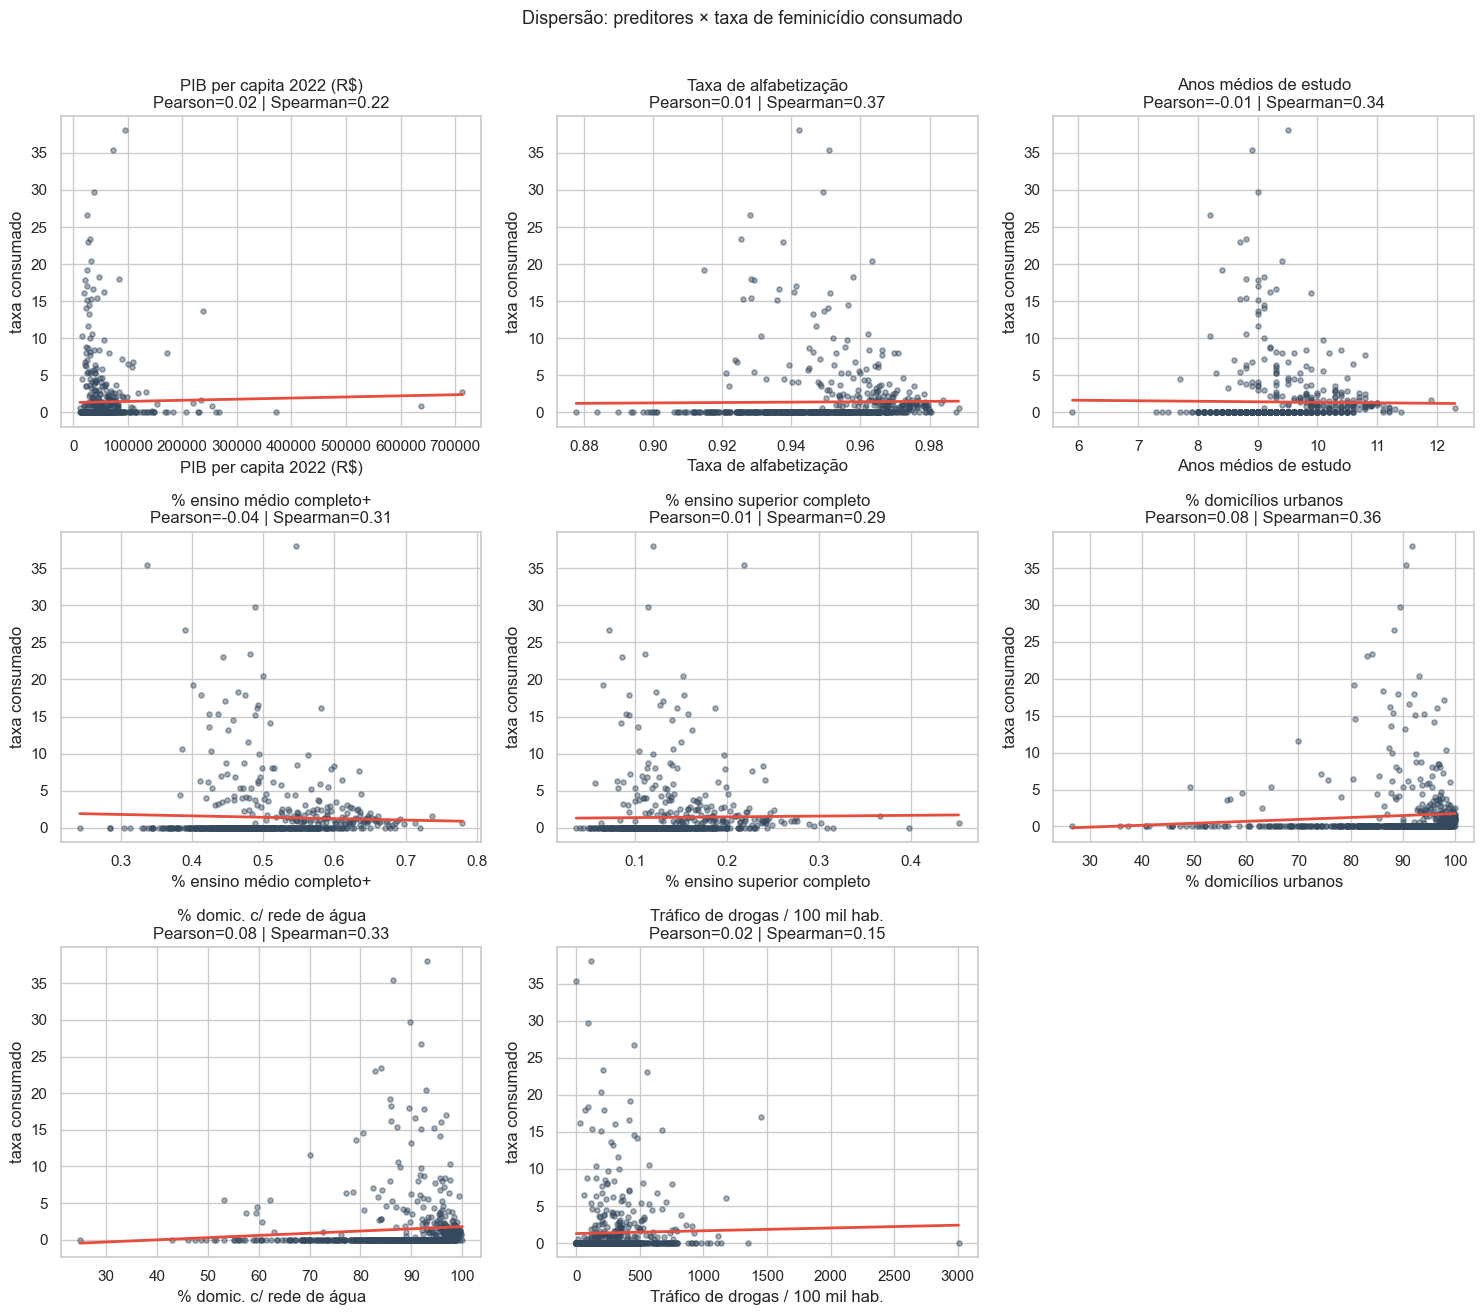

,preditor,Pearson,Spearman
0,PIB per capita 2022 (R$),0.019,0.215
1,Taxa de alfabetização,0.012,0.368
2,Anos médios de estudo,-0.013,0.340
3,% ensino médio completo+,-0.036,0.312
4,% ensino superior completo,0.013,0.294
5,% domicílios urbanos,0.079,0.363
6,% domic. c/ rede de água,0.079,0.335
7,Tráfico de drogas / 100 mil hab.,0.022,0.153


In [6]:
def spearman(a, b):
    return pd.concat([a, b], axis=1).rank().corr().iloc[0, 1]

fig, axes = plt.subplots(3, 3, figsize=(15, 13)); axes = axes.ravel()
linhas = []
for i, p in enumerate(PRED):
    r_p = cs[p].corr(cs[Y]); r_s = spearman(cs[p], cs[Y]); linhas.append((ROTULO[p], r_p, r_s))
    ax = axes[i]; ax.scatter(cs[p], cs[Y], s=14, alpha=.45, color="#34495e")
    b, a = np.polyfit(cs[p], cs[Y], 1); xs = np.linspace(cs[p].min(), cs[p].max(), 50)
    ax.plot(xs, a + b * xs, color="#e74c3c", lw=2)
    ax.set(title=f"{ROTULO[p]}\nPearson={r_p:.2f} | Spearman={r_s:.2f}", xlabel=ROTULO[p], ylabel="taxa consumado")
axes[-1].axis("off"); plt.suptitle("Dispersão: preditores × taxa de feminicídio consumado", y=1.01, fontsize=13)
plt.tight_layout(); plt.show()
pd.DataFrame(linhas, columns=["preditor", "Pearson", "Spearman"]).round(3)

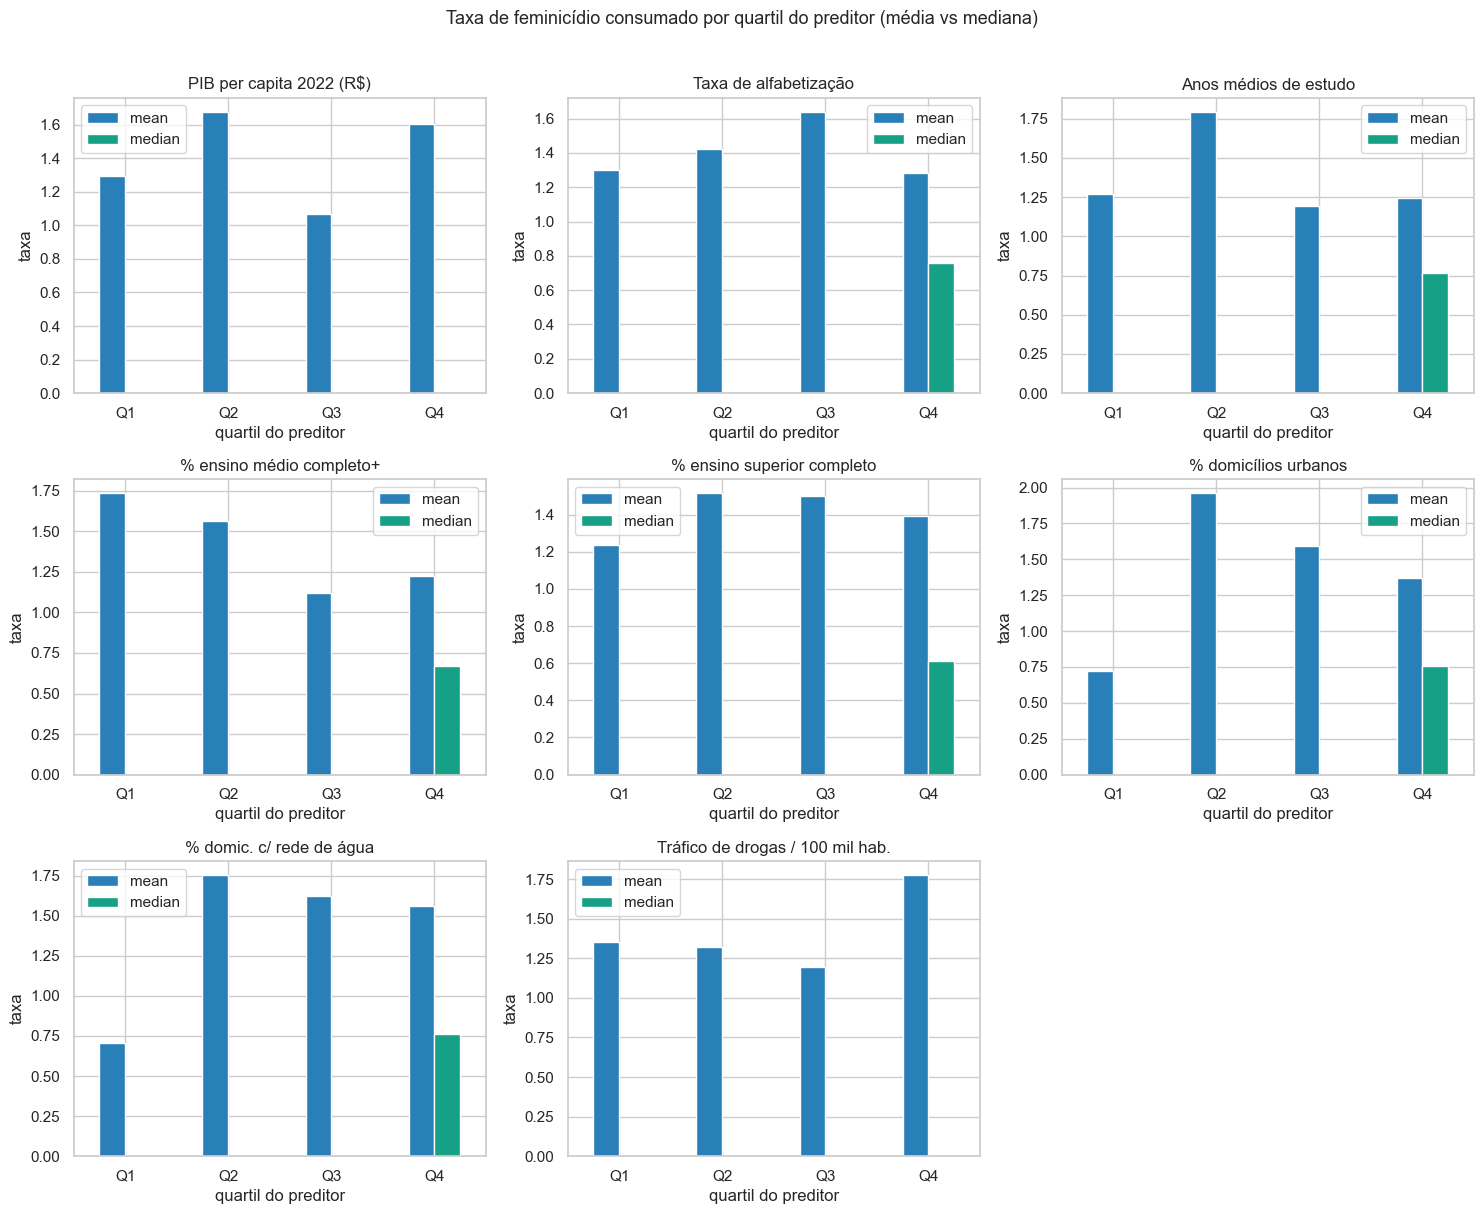

In [7]:
# quartis: média (inflada por outliers) vs mediana (carrega o sinal)
fig, axes = plt.subplots(3, 3, figsize=(15, 12)); axes = axes.ravel()
for i, p in enumerate(PRED):
    q = pd.qcut(cs[p], 4, labels=["Q1", "Q2", "Q3", "Q4"], duplicates="drop")
    g = cs.groupby(q, observed=True)[Y].agg(["mean", "median"])
    g.plot(kind="bar", ax=axes[i], rot=0, color=["#2980b9", "#16a085"])
    axes[i].set(title=ROTULO[p], xlabel="quartil do preditor", ylabel="taxa")
axes[-1].axis("off"); plt.suptitle("Taxa de feminicídio consumado por quartil do preditor (média vs mediana)", y=1.01, fontsize=13)
plt.tight_layout(); plt.show()

**Interpretação.** Padrão revelador: o **Pearson é ≈ 0** para todos os preditores (−0,04 a +0,08), mas o **Spearman é positivo e moderado** (+0,15 a +0,37). A divergência é diagnóstica — o Pearson é destruído pelo excesso de zeros e pela cauda longa; o Spearman (postos) enxerga uma **associação monotônica positiva**. Nos quartis, a **média** é plana e ruidosa (dominada por outliers), mas a **mediana só é positiva no quartil superior** de cada preditor: municípios mais escolarizados/ricos/urbanizados têm **maior probabilidade de registrar algum consumado**.

**As variáveis de contexto seguem o mesmo padrão.** `taxa_urbanizacao_pct` (Spearman **+0,36**) e `taxa_saneamento_basico_pct` (**+0,34**) reproduzem a assinatura dos socioeconômicos — Pearson ≈ 0, Spearman moderado — e estão, como eles, fortemente atadas à população (Spearman +0,64 e +0,55): **reforçam o mesmo confundimento por exposição**, não trazem um eixo novo. Já `taxa_trafico_drogas_100k` tem associação **mais fraca** (Spearman **+0,15**) e menor correlação com a população (+0,39) — coerente com ser um construto distinto (criminalidade), não um proxy de urbanização/desenvolvimento.

**⚠️ Confundimento por população.** Esse sinal é, em boa parte, **espúrio**, induzido pelo tamanho do município. A probabilidade de ≥1 consumado sobe de **7,9%** (terço de menor população) para **60,5%** (terço maior), e a população é positivamente correlacionada com **todos** os preditores (Spearman 0,39–0,72). Municípios maiores são simultaneamente mais ricos/educados/urbanizados **e** mais propensos a registrar eventos (mais exposição, menos zeros estruturais). A associação some no Pearson e aparece no Spearman porque é **mediada pela exposição populacional** — o que **reforça** o uso de um modelo de contagem com **offset `log(população)`**.

## 3. Multicolinearidade entre preditores

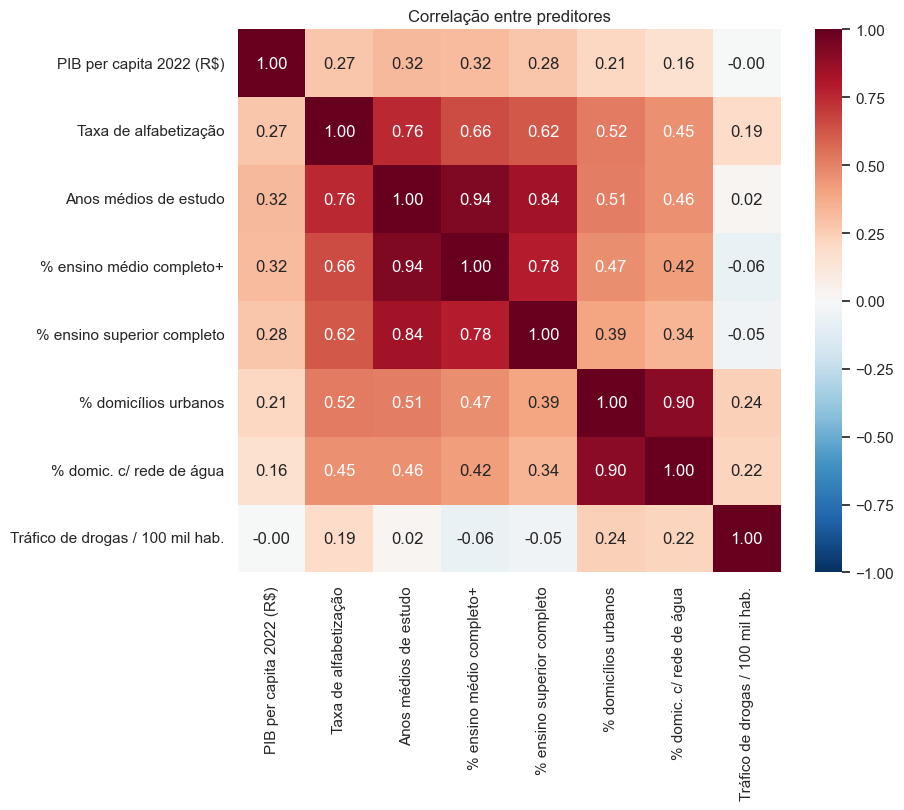

Pares |r|>0,80: [('anos_medios_estudo', 'pct_ensino_medio', np.float64(0.94)), ('anos_medios_estudo', 'pct_ensino_superior', np.float64(0.84)), ('taxa_urbanizacao_pct', 'taxa_saneamento_basico_pct', np.float64(0.9))]

VIF - todos os 8:
pib_per_capita_2022            1.13
taxa_alfabetizacao             2.71
anos_medios_estudo            14.74
pct_ensino_medio               8.89
pct_ensino_superior            3.54
taxa_urbanizacao_pct           6.16
taxa_saneamento_basico_pct     5.58
taxa_trafico_drogas_100k       1.19

VIF - nucleo {pib, alfabetizacao, anos de estudo}:
pib_per_capita_2022    1.12
taxa_alfabetizacao     2.35
anos_medios_estudo     2.42

VIF - recomendado + contexto (pib, alfab., anos estudo, urbanizacao, trafico):
pib_per_capita_2022         1.12
taxa_alfabetizacao          2.61
anos_medios_estudo          2.68
taxa_urbanizacao_pct        1.51
taxa_trafico_drogas_100k    1.14


In [8]:
cm = cs[PRED].corr()
fig, ax = plt.subplots(figsize=(9.5, 8))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, square=True,
            xticklabels=[ROTULO[p] for p in PRED], yticklabels=[ROTULO[p] for p in PRED], ax=ax)
ax.set_title("Correlação entre preditores"); plt.tight_layout(); plt.show()

pares = [(PRED[i], PRED[j], round(cm.iloc[i, j], 2)) for i in range(len(PRED))
         for j in range(i + 1, len(PRED)) if abs(cm.iloc[i, j]) > .8]
print("Pares |r|>0,80:", pares)

def vif(df, cols):
    X = df[cols].to_numpy(float); out = {}
    for i, c in enumerate(cols):
        y = X[:, i]; Z = np.column_stack([np.ones(len(X)), np.delete(X, i, 1)])
        b, *_ = np.linalg.lstsq(Z, y, rcond=None); r2 = 1 - ((y - Z @ b) ** 2).sum() / ((y - y.mean()) ** 2).sum()
        out[c] = round(1 / (1 - r2), 2)
    return pd.Series(out)

print("\nVIF - todos os 8:");                                    print(vif(cs, PRED).to_string())
print("\nVIF - nucleo {pib, alfabetizacao, anos de estudo}:");   print(vif(cs, ["pib_per_capita_2022", "taxa_alfabetizacao", "anos_medios_estudo"]).to_string())
print("\nVIF - recomendado + contexto (pib, alfab., anos estudo, urbanizacao, trafico):")
print(vif(cs, ["pib_per_capita_2022", "taxa_alfabetizacao", "anos_medios_estudo", "taxa_urbanizacao_pct", "taxa_trafico_drogas_100k"]).to_string())

**Interpretação.** Entre os preditores fixos, dois pares ultrapassam |r| > 0,80, ambos com `anos_medios_estudo`: contra `pct_ensino_medio` (**0,94**) e contra `pct_ensino_superior` (**0,84**). O VIF confirma: com todos os preditores juntos, `anos_medios_estudo` tem **VIF ≈ 14,7** e `pct_ensino_medio` ≈ 8,9 — colinearidade severa (regra usual: VIF > 5–10).

**Com as variáveis de contexto, surge um terceiro par redundante.** `taxa_urbanizacao_pct` × `taxa_saneamento_basico_pct` têm **r = 0,90**: medem essencialmente a mesma dimensão (infraestrutura urbana). Postas juntas no conjunto, seus VIF sobem para **6,2** e **5,6**; mantendo **apenas uma**, ambos caem para ~1,4. Já `taxa_trafico_drogas_100k` é praticamente **ortogonal** aos demais (**VIF 1,14**) — carrega informação genuinamente nova.

**Decisões.** (i) `anos_medios_estudo` e `pct_ensino_medio` medem quase a mesma coisa (r = 0,94) → mantemos **`anos_medios_estudo`** (contínuo, interpretável) e descartamos `pct_ensino_medio`. (ii) Entre urbanização e saneamento, mantemos **uma** — `taxa_urbanizacao_pct` (ligeiramente mais associada ao desfecho e o confundidor já nomeado na EDA; saneamento é intercambiável).

**Conjunto recomendado para a modelagem:** `pib_per_capita_2022` + `taxa_alfabetizacao` + `anos_medios_estudo` + `taxa_urbanizacao_pct` + `taxa_trafico_drogas_100k` → **todos com VIF ≤ 2,7**. (Acrescenta infraestrutura urbana e criminalidade ao núcleo socioeconômico, sem reintroduzir colinearidade.)

## 4. Análise espacial

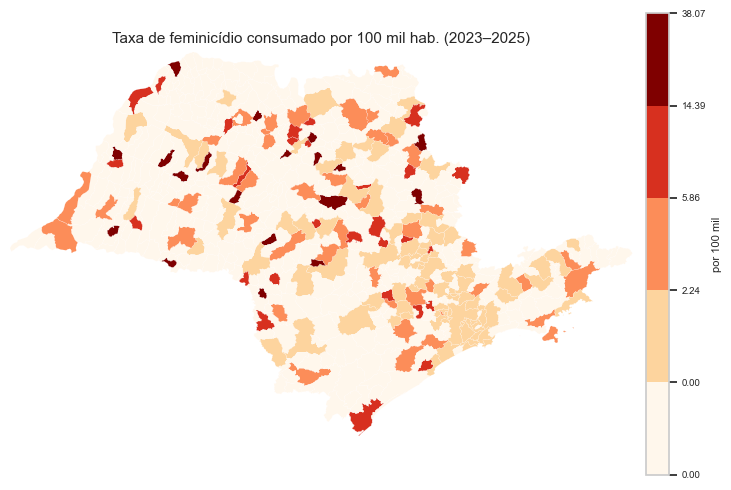

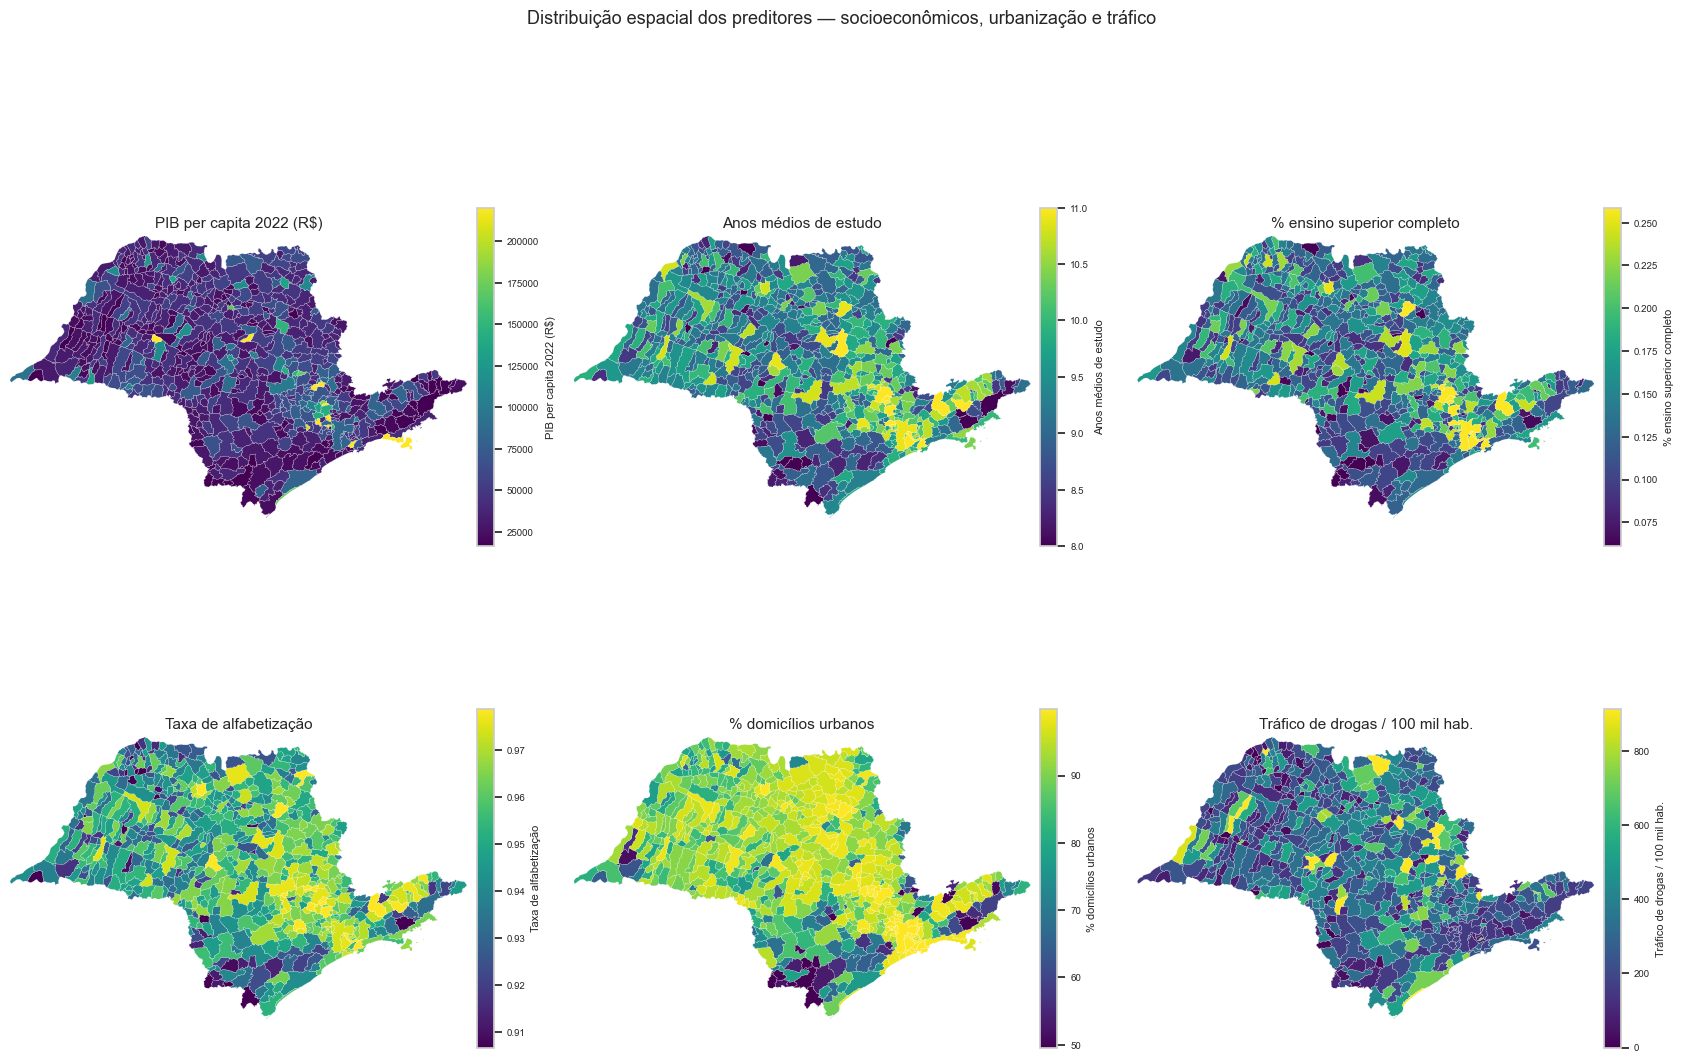

In [9]:
import urllib.request, gzip
# Malha municipal do IBGE (para os mapas). Procura um arquivo local; se não houver,
# baixa automaticamente (requer internet). Assim o notebook roda só com ele + o CSV.
CAND = ["sp_municipios.geojson", "../raw/geo/sp_municipios.geojson", "raw/geo/sp_municipios.geojson"]
GEO = next((p for p in CAND if os.path.exists(p)), "sp_municipios.geojson")
if not os.path.exists(GEO):
    url = ("https://servicodados.ibge.gov.br/api/v3/malhas/estados/35"
           "?formato=application/vnd.geo+json&intrarregiao=municipio&qualidade=intermediaria")
    raw = urllib.request.urlopen(urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"}), timeout=30).read()
    if raw[:2] == b"\x1f\x8b": raw = gzip.decompress(raw)
    open(GEO, "wb").write(raw)
geo = json.load(open(GEO, encoding="utf-8"))
geom_by_code = {int(f["properties"]["codarea"]): f["geometry"] for f in geo["features"]}

def rings(geom):
    polys = [geom["coordinates"]] if geom["type"] == "Polygon" else geom["coordinates"]
    for poly in polys:
        yield np.asarray(poly[0])

def choropleth(ax, vbi, title, cmap="viridis", boundaries=None, label=""):
    patches, data = [], []; bb = [1e9, 1e9, -1e9, -1e9]
    for code, geom in geom_by_code.items():
        v = vbi.get(code, np.nan)
        for ring in rings(geom):
            patches.append(MplPoly(ring, closed=True)); data.append(v)
            bb = [min(bb[0], ring[:, 0].min()), min(bb[1], ring[:, 1].min()),
                  max(bb[2], ring[:, 0].max()), max(bb[3], ring[:, 1].max())]
    data = np.asarray(data, float)
    if boundaries is not None:
        cmap_o = plt.get_cmap(cmap, len(boundaries) - 1); norm = mcolors.BoundaryNorm(boundaries, cmap_o.N)
    else:
        cmap_o = plt.get_cmap(cmap); norm = mcolors.Normalize(np.nanpercentile(data, 2), np.nanpercentile(data, 98))
    pc = PatchCollection(patches, cmap=cmap_o, norm=norm, edgecolor="white", linewidth=.12); pc.set_array(data)
    ax.add_collection(pc); ax.set_xlim(bb[0], bb[2]); ax.set_ylim(bb[1], bb[3])
    ax.set_aspect("equal"); ax.axis("off"); ax.set_title(title, fontsize=11)
    cb = plt.colorbar(pc, ax=ax, fraction=.035, pad=.02); cb.set_label(label, fontsize=8); cb.ax.tick_params(labelsize=7)

# desfecho: cinza claro = sem consumado; positivos em quartis (OrRd)
t = cs.set_index("id_municipio")[Y]; pos = t[t > 0]
bnd = sorted(set([0, 1e-9, pos.quantile(.5), pos.quantile(.75), pos.quantile(.9), float(t.max()) * 1.001]))
fig, ax = plt.subplots(figsize=(8.5, 8.5))
choropleth(ax, t.to_dict(), "Taxa de feminicídio consumado por 100 mil hab. (2023–2025)", cmap="OrRd", boundaries=bnd, label="por 100 mil")
plt.show()

maps = ["pib_per_capita_2022", "anos_medios_estudo", "pct_ensino_superior",
        "taxa_alfabetizacao", "taxa_urbanizacao_pct", "taxa_trafico_drogas_100k"]
fig, axes = plt.subplots(2, 3, figsize=(17, 12)); axes = axes.ravel()
for i, p in enumerate(maps):
    choropleth(axes[i], cs.set_index("id_municipio")[p].to_dict(), ROTULO[p], cmap="viridis", label=ROTULO[p])
plt.suptitle("Distribuição espacial dos preditores — socioeconômicos, urbanização e tráfico", y=1.0, fontsize=13)
plt.tight_layout(); plt.show()

**Interpretação.** O mapa do desfecho confirma o excesso de zeros: a maior parte do território (municípios pequenos do interior) aparece **sem consumado** (tom claro). Os municípios com taxa positiva estão **dispersos**, sem um aglomerado único óbvio. Já os mapas dos preditores mostram **estrutura espacial clara**: a região metropolitana e o eixo sudeste/litoral são mais ricos (PIB per capita), escolarizados e **urbanizados**; o oeste/noroeste tem indicadores mais baixos. O mapa do **tráfico** é distinto — mais difuso e puxado pelos centros urbanos maiores —, coerente com sua baixa correlação bivariada e com ser um eixo independente.

A combinação é coerente com o **confundimento por população/urbanização**: as áreas mais urbanizadas concentram tanto melhores indicadores socioeconômicos quanto maior probabilidade de registro de eventos. A inspeção visual sugere **autocorrelação espacial nos preditores** e padrão **mais difuso no desfecho** — mas isso exige teste formal: recomenda-se o **I de Moran** (e, se significativo, modelos espaciais SAR/CAR) na etapa de modelagem. *(Não calculado aqui por ausência de biblioteca espacial no ambiente.)*

## 5. Síntese da EDA

- **Distribuição do desfecho:** fortemente assimétrica à direita (skew ≈ 4,8), mediana 0, cauda até ~38/100 mil.
- **Excesso de zeros:** **71,3%** dos municípios sem nenhum feminicídio consumado em 2023–2025.
- **Principais associações:** Pearson ≈ 0; Spearman positivo e moderado (0,15–0,37). O sinal está na **ocorrência** (ter ou não ≥1 caso), não na magnitude linear — a mediana da taxa só é positiva no quartil superior dos preditores.
- **Variáveis de contexto:** urbanização e saneamento repetem a assinatura dos socioeconômicos (Spearman +0,36/+0,34, atados à população) → reforçam o confundimento, sem eixo novo. Tráfico é mais fraco (Spearman +0,15) porém **ortogonal** (VIF 1,14): único preditor que varia no tempo e candidato a sinal independente.
- **Confundimento-chave:** **população** correlaciona com o desfecho (Spearman 0,46) e com todos os preditores (0,39–0,72); P(≥1 consumado) vai de 7,9% (pequenos) a 60,5% (grandes). A associação bivariada é, em boa parte, **mediada pela exposição**.
- **Multicolinearidade:** três pares redundantes — `anos_medios_estudo` × `pct_ensino_medio` (r = 0,94) e `taxa_urbanizacao_pct` × `taxa_saneamento_basico_pct` (r = 0,90). Decisão: manter `anos_medios_estudo` e **uma** proxy de infraestrutura (`taxa_urbanizacao_pct`). Conjunto final: `pib_per_capita_2022` + `taxa_alfabetizacao` + `anos_medios_estudo` + `taxa_urbanizacao_pct` + `taxa_trafico_drogas_100k` (VIF ≤ 2,7).
- **Padrões espaciais:** estrutura nítida nos preditores socioeconômicos e de urbanização (eixo metropolitano/sudeste); desfecho e tráfico mais difusos. Testar **I de Moran** antes de assumir modelo espacial.
- **Implicação para o modelo econométrico:** descartar OLS sobre a taxa. Usar **modelo de contagem** sobre `n_consumado` com **offset `log(população)`** (Poisson → Binomial Negativa se sobredispersão), avaliando **inflação de zeros** (zero-inflated/hurdle). A população entra como **exposição**, não como mais um preditor.

## Limitações e próximos passos

**Limitações desta etapa.**
- Preditores cobrem renda, educação, **infraestrutura urbana** (urbanização/saneamento) e **criminalidade** (tráfico); todos **fixos em 2022**, *exceto* o tráfico, que varia 2022–2025.
- `pib_per_capita` é distorcido por enclaves industriais (ver 2.4).
- Urbanização e saneamento são, em boa parte, **proxies do mesmo confundidor populacional** — agregam pouco eixo novo de variação.
- Faltam construtos que a teoria sugere: **desigualdade** (Gini/pobreza) e, sobretudo, **desigualdade de gênero** (participação feminina no mercado, gap salarial, representação política).
- A associação bivariada está **confundida pela população** (seção 2 da EDA).

**Próximos passos sugeridos.**
1. **Fase 2 de enriquecimento:** rendimento domiciliar per capita (no lugar do PIB-enclave), indicadores de desigualdade e de gênero — idealmente fontes que *variam no tempo*.
2. **Teste de I de Moran** para confirmar autocorrelação espacial.
3. **Modelagem:** contagem sobre `n_consumado` com **offset `log(população)`** (Poisson → Binomial Negativa se houver sobredispersão), avaliando **inflação de zeros** (zero-inflated/hurdle). Preditores recomendados: `pib_per_capita_2022` + `taxa_alfabetizacao` + `anos_medios_estudo` + `taxa_urbanizacao_pct` + `taxa_trafico_drogas_100k` (VIF ≤ 2,7).

---
*Notebook autocontido — bastam `analise_final.ipynb` + `painel_feminicidio_sp.csv`. Os mapas baixam a malha do IBGE automaticamente. Construção da base: ver `docs/` no repositório.*